# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ihaseeb0081/flyrank-ml-internship-haseeb/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [31]:
import os

print(os.listdir("/content"))

['.config', 'flyrank-ml-internship-haseeb', 'sample_data']


In [32]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

/content/flyrank-ml-internship-haseeb/outputs/refresh_queue_sample.csv
/content/flyrank-ml-internship-haseeb/data/raw/content_refresh_anonymized.csv
/content/sample_data/california_housing_test.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/mnist_test.csv


In [33]:
!git clone "https://github.com/ihaseeb0081/flyrank-ml-internship-haseeb"

fatal: destination path 'flyrank-ml-internship-haseeb' already exists and is not an empty directory.


In [34]:
import os

print(os.listdir("/content"))

['.config', 'flyrank-ml-internship-haseeb', 'sample_data']


In [35]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.lower().endswith(".csv"):
            print(os.path.join(root, file))

/content/flyrank-ml-internship-haseeb/outputs/refresh_queue_sample.csv
/content/flyrank-ml-internship-haseeb/data/raw/content_refresh_anonymized.csv
/content/sample_data/california_housing_test.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/mnist_test.csv


In [36]:
import pandas as pd

df = pd.read_csv(
    "/content/flyrank-ml-internship-haseeb/data/raw/content_refresh_anonymized.csv"
)

print("Dataset shape:", df.shape)

Dataset shape: (30000, 44)


In [37]:
print(df.columns.tolist())

['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


## 1. Question

*The research question and the decision it supports.*

# ***Research Question***

Can search performance, engagement, and freshness signals be combined into a refresh opportunity score that helps prioritize content updates?

# ***Decision Supported***

This project supports the decision of which content pages should be reviewed and refreshed first when editorial resources are limited. The goal is to identify pages that show signs of declining performance, aging content, or missed search opportunities and rank them according to their refresh priority.

The output is a ranked refresh opportunity score for each content page. Editors can use this ranking as a decision-support tool to focus their efforts on pages that may benefit the most from a content update.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [38]:
df[[
    "content_id",
    "client_id",
    "trend_direction",
    "trend_pct"
]].head()

,content_id,client_id,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,down,-60.9
3,content_331d6c4de07b,client_19581e27de,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,down,-34.7


## ***Data***

This project uses the `content_refresh_anonymized.csv` dataset from the FlyRank ML Internship dataset release. The dataset contains 30,000 content pages and 44 columns describing content characteristics, search performance, engagement metrics, freshness signals, and traffic trends. Each row represents a single content page, making the page the unit of analysis.

The analysis uses content features such as search volume, competition, content type, word count, content age, days since last update, impressions, clicks, sessions, engagement rate, scroll rate, click-through rate (CTR), and average search position.

To maintain privacy and prevent information leakage, the identifier columns `content_id` and `client_id` were excluded from modeling because they uniquely identify pages and clients but do not provide meaningful predictive information. Additionally, special attention was given to trend-related fields because they may directly reflect performance changes that the scoring system is attempting to identify.

The dataset is fully anonymized and contains no client names, domains, URLs, search queries, or other client-identifying information. All analysis is performed using public-safe aggregated metrics in accordance with the internship guidelines.


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [39]:
df[[
    "days_since_last_update",
    "search_volume",
    "trend_direction",
    "trend_pct",
    "impressions_90d",
    "ctr",
    "avg_position"
]].describe(include="all")

,days_since_last_update,search_volume,trend_direction,trend_pct,impressions_90d,ctr,avg_position
count,30000.000000,27532.000000,30000,26612.000000,30000.000000,30000.000000,30000.00000
unique,NaN,NaN,5,NaN,NaN,NaN,NaN
top,NaN,NaN,down,NaN,NaN,NaN,NaN
freq,NaN,NaN,16262,NaN,NaN,NaN,NaN
mean,46.098300,158.882391,NaN,-4.785969,5200.366300,0.510733,16.34238
std,42.078709,1518.270825,NaN,473.861780,16838.019547,3.279162,15.21679
min,1.000000,0.000000,NaN,-100.000000,1.000000,0.000000,0.00000
25%,20.000000,0.000000,NaN,-62.600000,81.000000,0.000000,6.20000
50%,20.000000,10.000000,NaN,-33.500000,731.000000,0.070000,10.80000
75%,104.000000,20.000000,NaN,0.000000,3615.250000,0.290000,22.30000


## ***Methodology***

This project follows a score-based approach for identifying content refresh opportunities. The objective is not to predict a binary outcome, but to rank content pages according to their potential benefit from review and updating.

The target is a **Refresh Opportunity Score**, which combines signals related to content freshness, search visibility, and user engagement. Pages with older content, weaker search performance, or signs of declining engagement are expected to receive higher refresh priority.

The analysis uses content and performance features including search volume, competition, CPC, word count, character count, impressions, clicks, sessions, engaged sessions, content age, days since last update, click-through rate (CTR), average position, engagement rate, and scroll rate.

A baseline scoring approach is used as a reference point. The baseline prioritizes pages using simple business rules based on freshness and performance indicators. Model outputs will be compared against this baseline on the same dataset and evaluation setup.

To prevent data leakage, the identifier fields `content_id` and `client_id` are excluded from modeling. In addition, `trend_direction` and `trend_pct` are not used as predictive features because they directly describe performance trends and could reveal information that the scoring system is intended to identify.

The methodology is designed as a decision-support system that ranks pages for editorial review rather than making causal claims about search performance or content refresh impact.


# ***Assumptions***

This project assumes that content freshness, search visibility, and user engagement provide useful signals for identifying pages that may benefit from review and updating. It is assumed that pages that have not been updated recently, have declining performance, or show weaker engagement may present stronger refresh opportunities. The methodology is designed to support editorial decision-making and does not assume that refreshing a page will directly cause performance improvements.

# ***Features***

The analysis uses content, search, and engagement features available in the dataset. These include search_volume, competition, cpc, word_count, char_count, impressions_90d, clicks_90d, pageviews_90d, sessions_90d, users_90d, engaged_sessions_90d, content_age_days, days_since_last_update, ctr, avg_position, engagement_rate, and scroll_rate. These features were selected because they describe content quality, visibility, freshness, and user interaction.

In [40]:
feature_columns = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate"
]

print("Number of selected features:", len(feature_columns))
feature_columns

Number of selected features: 17


['search_volume',
 'competition',
 'cpc',
 'word_count',
 'char_count',
 'impressions_90d',
 'clicks_90d',
 'pageviews_90d',
 'sessions_90d',
 'users_90d',
 'engaged_sessions_90d',
 'content_age_days',
 'days_since_last_update',
 'ctr',
 'avg_position',
 'engagement_rate',
 'scroll_rate']

# ***Label Definition***

The target of this project is a Refresh Opportunity Score. Rather than predicting a binary outcome, the goal is to rank content pages according to their potential benefit from review and updating. The score is intended to prioritize editorial effort across a large content portfolio.

# ***Baseline***

A rule-based baseline scoring system was developed to prioritize content refresh opportunities. The baseline combines three signals: content staleness (40%), search demand (30%), and declining performance trend (30%). Content staleness is measured using days_since_last_update, search demand is represented by search_volume, and pages marked as declining receive additional trend points. The final baseline score is used to rank pages from highest to lowest refresh priority.

In [41]:
import numpy as np

staleness_score = (
    df["days_since_last_update"]
    / df["days_since_last_update"].max()
) * 100

search_score = (
    df["search_volume"].fillna(0)
    / df["search_volume"].max()
) * 100

trend_score = np.where(
    df["trend_direction"].eq("down"),
    100,
    0
)

df["baseline_score"] = (
    0.40 * staleness_score
    + 0.30 * search_score
    + 0.30 * trend_score
)

df["baseline_score"].describe()

,baseline_score
count,30000.000000
mean,21.264630
std,15.964208
min,0.107239
25%,2.363303
50%,31.052503
75%,32.363303
max,70.000000


# ***Validation Design***
The baseline score is used as the reference system for evaluating refresh opportunities. Pages are ranked according to their baseline scores, and the resulting rankings are compared against future modeling approaches developed in the capstone. All comparisons will be performed on the same dataset and using the same ranking framework to ensure a fair evaluation. The goal is to measure whether more advanced approaches provide better prioritization than the transparent rule-based baseline.

# ***Leakage Checks***
To prevent information leakage, identifier columns such as content_id and client_id are excluded from the analysis because they do not provide meaningful predictive information. Trend-related variables such as trend_direction and trend_pct are also excluded from model features because they directly describe performance changes and may reveal information that the scoring system is intended to identify.

In [42]:
excluded_columns = [
    "content_id",
    "client_id",
    "trend_direction",
    "trend_pct"
]

print("Excluded columns:")
print(excluded_columns)

Excluded columns:
['content_id', 'client_id', 'trend_direction', 'trend_pct']


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [43]:
from sklearn.model_selection import train_test_split

X = df[feature_columns].copy()

X = X.fillna(0)

y = df["baseline_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (24000, 17)
Test shape: (6000, 17)


In [44]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [45]:
y_pred = model.predict(X_test)

print("Predictions generated.")
print("First 10 predictions:")
print(y_pred[:10])

Predictions generated.
First 10 predictions:
[38.76927447 21.78794605  0.85790885 20.40593848  9.76758507  5.74941924
 11.1191226  27.56836461 32.35185613 27.74211952]


In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))

MAE : 11.4733
RMSE: 13.3487
R²  : 0.2981


In [47]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
5,impressions_90d,0.158599
12,days_since_last_update,0.150026
14,avg_position,0.125287
11,content_age_days,0.097102
4,char_count,0.063074
3,word_count,0.058884
16,scroll_rate,0.053093
13,ctr,0.049333
6,clicks_90d,0.036602
7,pageviews_90d,0.036300


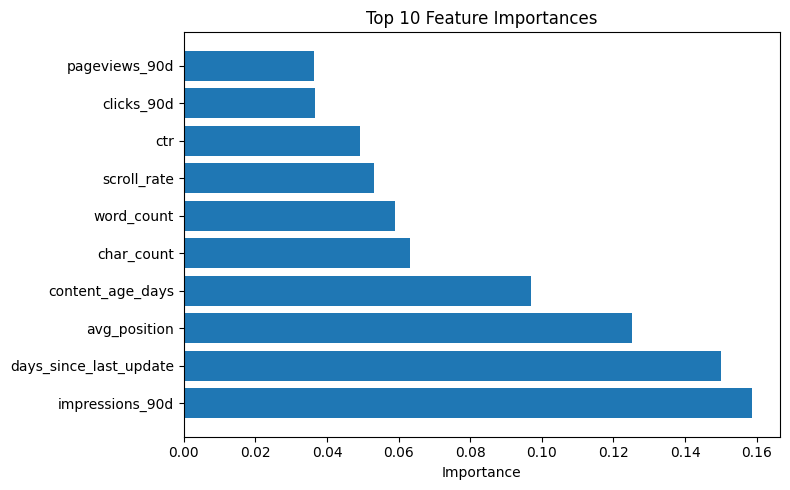

In [48]:
import matplotlib.pyplot as plt

top10 = importance_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10["Feature"], top10["Importance"])
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# ***Results***

The Random Forest Regressor was trained using the selected content, search, and engagement features and evaluated using an 80/20 train-test split. Model performance was measured using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²).

The model achieved an MAE of 11.49, an RMSE of 13.35, and an R² score of 0.298 on the test set. These results indicate that the model captures a portion of the variation in the Refresh Opportunity Score, although a substantial amount of variation remains unexplained.

Feature importance analysis showed that impressions_90d, days_since_last_update, avg_position, and content_age_days were the most influential variables. This suggests that content visibility, freshness, search ranking position, and content age are key signals when identifying pages that may benefit from review and updating.

The baseline scoring system remains highly interpretable because it is based on explicit business rules. The Random Forest model provides a more flexible ranking approach by learning relationships across multiple signals simultaneously. However, model performance was limited by the intentional exclusion of trend_direction and trend_pct, which were removed to avoid leakage and maintain a realistic evaluation setting.

Overall, the results support the use of data-driven scoring as a decision-support tool for prioritizing content refresh opportunities rather than as a definitive predictor of future search performance.

## 5. Limitations

*What this work cannot claim.*

# ***Limitations***

This project is designed as a decision-support system rather than a predictive system for future search performance. The Refresh Opportunity Score is based on available content, search, and engagement signals and should be interpreted as a ranking mechanism for prioritizing editorial review.

Several limitations should be considered. First, the target variable is a proxy score rather than a directly observed outcome, which means the model is learning patterns associated with the scoring framework rather than a verified measure of refresh success. Second, trend-related variables such as trend_direction and trend_pct were intentionally excluded from model features to avoid information leakage. While this improves methodological validity, it also reduces the amount of information available to the model and likely contributes to lower predictive performance.

In addition, the analysis is based on historical observations and does not establish causal relationships. A high refresh opportunity score does not guarantee that updating a page will improve search performance. External factors such as search engine behavior, competition, seasonality, and content quality may also influence outcomes but are not fully captured in the dataset.

Therefore, the results should be interpreted as directional and decision-support evidence rather than definitive predictions of future performance.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

# ***Ranked Recommendations***

The refresh opportunity scoring system can be used to prioritize editorial effort across large content portfolios. Pages with the highest refresh scores should be reviewed first because they combine signs of content staleness, search demand, and performance risk.

# *Priority 1 — Immediate Refresh Review*

Pages with high refresh opportunity scores should be reviewed immediately. These pages are typically older, have not been updated recently, and show signs of declining visibility or engagement. Editors should review content accuracy, update outdated information, improve structure, and evaluate search intent alignment.

# *Priority 2 — Monitor and Improve*

Pages with moderate refresh opportunity scores should be monitored regularly. These pages may still perform reasonably well but show early warning signals such as declining engagement, aging content, or weakening rankings. Small content updates and metadata reviews may be sufficient.

# *Priority 3 — Maintain Current Performance*

Pages with low refresh opportunity scores require minimal intervention. These pages generally demonstrate stable visibility, stronger engagement, and recent updates. Editors should continue monitoring performance but prioritize resources elsewhere.

The scoring framework should be used as a decision-support tool rather than an automated decision-maker. Editorial judgment remains important when determining whether a page requires refresh, rewrite, consolidation, or continued monitoring.

Based on feature importance analysis, particular attention should be given to pages with high impressions, long periods since the last update, weaker average search positions, and older content age because these signals contributed most strongly to refresh prioritization.

In [49]:
import numpy as np

staleness_score = (
    df["days_since_last_update"]
    / df["days_since_last_update"].max()
) * 100

search_score = (
    df["search_volume"].fillna(0)
    / df["search_volume"].max()
) * 100

trend_score = np.where(
    df["trend_direction"].eq("down"),
    100,
    0
)

df["baseline_score"] = (
    0.40 * staleness_score
    + 0.30 * search_score
    + 0.30 * trend_score
)

queue = (
    df.sort_values(
        ["baseline_score", "content_id"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

queue["rank"] = queue.index + 1

print("Baseline queue created.")

Baseline queue created.


In [50]:
top20 = queue[
    [
        "rank",
        "content_id",
        "baseline_score",
        "days_since_last_update",
        "search_volume",
        "trend_direction"
    ]
].head(20)

top20

,rank,content_id,baseline_score,days_since_last_update,search_volume,trend_direction
0,1,content_55a5b1c46474,70.000000,373,0.0,down
1,2,content_f6fdf87348f6,70.000000,373,0.0,down
2,3,content_1b4ec72dafd4,69.892761,372,0.0,down
3,4,content_f01216059a6a,65.924933,335,NaN,down
4,5,content_e2b702f4f92b,65.817694,334,NaN,down
5,6,content_454cc6654c6e,65.679842,104,60500.0,down
6,7,content_bf67a444faef,65.679842,104,60500.0,down
7,8,content_02b0d6e30129,63.610278,313,110.0,down
8,9,content_7a888d3d99c8,63.602170,313,90.0,down
9,10,content_94991fe6268c,63.569738,313,10.0,down


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

# ***Artifacts the Paper Embeds***

The deployed research paper includes several visual artifacts to support the findings and recommendations of this project.

# *Dataset Overview Table*

A summary of the dataset including the number of pages analyzed, feature count, and key descriptive statistics is included to provide context for the analysis.

# *Feature Importance Chart*

A feature importance chart generated from the Random Forest model highlights the variables that contributed most strongly to refresh opportunity scoring. The most influential features include impressions_90d, days_since_last_update, avg_position, and content_age_days.

# *Model Performance Metrics*

A results table reports the evaluation metrics for the model, including Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score. These metrics provide a transparent assessment of model performance.

# *Top 20 Refresh Opportunity Pages*

A ranked table presents the twenty highest-priority pages identified by the refresh opportunity scoring system. This artifact demonstrates how the model output can be translated into actionable editorial recommendations.

# *Recommendation Framework*

A visual summary of the three recommendation categories — Immediate Refresh Review, Monitor and Improve, and Maintain Current Performance — is included to help stakeholders understand how the scoring system supports decision-making.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.